# Pool-based Multilabel Active Learning - Getting Started

This notebook introduces a compact multilabel active learning workflow with `scikit-activeml`.
We use BirdSet embeddings as a realistic feature pool, but the focus stays on the workflow itself: how multilabel targets are represented, how a classifier and query strategies are connected, and how to read the resulting learning curves.

You will learn:
- how to prepare BirdSet embeddings and multilabel targets for `scikit-activeml`,
- how `MISSING_LABEL` represents unknown labels in the unlabeled pool,
- how to compare a few multilabel-capable query strategies in one active-learning loop,
- how to interpret one concise result plot and final metric summary.


> **_Google Colab Note:_** If the notebook fails to run after installing the needed packages, try restarting the runtime after the installation cell finishes.

**Notebook Dependencies**

Uncomment the next cell if you need to install the dependencies for this tutorial. The notebook can reuse an existing `BirdSet_BASEAL` directory or download the official archive from Zenodo when the data is missing.

In [1]:
# %pip install scikit-activeml[opt] tqdm skorch torch matplotlib

## General

In multilabel classification, each sample is associated with a binary indicator vector such as `[1, 0, 1, 0, ...]` because several classes may be active at the same time.

Inside the active-learning loop, we keep two versions of the pool labels:
- `Y_train`: the full multilabel targets, which act as the oracle,
- `Y_known`: the currently revealed labels, where unknown entries are stored as `MISSING_LABEL`.

Each cycle follows the same pattern: fit on the currently known labels, query the next batch, reveal the true labels for that batch, refit the classifier, and evaluate on a fixed assessment split.


## Imports and Runtime Setup

The imports below show the core pieces of the tutorial: BirdSet data loading, multilabel metrics, a `SkorchClassifier`, and three pool-based query strategies.

In [2]:
import csv
import json
import warnings
import urllib.request
import zipfile
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm.auto import tqdm

from sklearn.metrics import average_precision_score, f1_score

from skactiveml.classifier import SkorchClassifier
from skactiveml.pool import CoreSet, RandomSampling, SubSamplingWrapper, UHerding
from skactiveml.utils import MISSING_LABEL, call_func

from skorch.callbacks import LRScheduler
from torch import nn
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")
mpl.rcParams["figure.facecolor"] = "white"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## Configuration

These are the few parameters worth changing first:
- `DATA_ROOT` points to an existing BirdSet export if you already have one,
- `DATASET_NAME` selects one multilabel pool,
- `INITIAL_LABELS`, `QUERY_BATCH_SIZE`, and `N_CYCLES` define the annotation budget,
- `SELECTED_STRATEGIES` lets you swap query strategies without touching the loop.


In [3]:
REPO_ROOT = Path.cwd()
DATA_ROOT = REPO_ROOT / "BirdSet_BASEAL"
DATASET_NAME = "HSN_BASEAL"
ASSESSMENT_SPLIT = "validation"

INITIAL_LABELS = 150
QUERY_BATCH_SIZE = 75
N_CYCLES = 8
N_REPETITIONS = 5
BASE_SEED = 42
SELECTED_STRATEGIES = ["Random", "CoreSet", "UHerding"]

LABELS_FILENAME = "labels.csv"
METADATA_FILENAME = "metadata.csv"
EMBEDDING_SUBDIR = Path("embeddings") / "perch_v2"
LABEL_SEPARATOR = ";"

ZENODO_RECORD_URL = "https://zenodo.org/api/records/19340660"
ZENODO_ARCHIVE_NAME = "BirdSet_BASEAL.zip"
KEEP_DOWNLOADED_ARCHIVE = False

MODEL_MAX_EPOCHS = 15
MODEL_BATCH_SIZE = 32
MODEL_LEARNING_RATE = 0.01
MAX_CANDIDATES = 2000

REPETITION_SEEDS = BASE_SEED + np.arange(N_REPETITIONS)

print(f"Dataset: {DATASET_NAME}")
print(f"Assessment split: {ASSESSMENT_SPLIT}")
print(f"Initial labels: {INITIAL_LABELS}")
print(f"Batch size: {QUERY_BATCH_SIZE}")
print(f"Cycles: {N_CYCLES}")
print(f"Strategies: {SELECTED_STRATEGIES}")

Dataset: HSN_BASEAL
Assessment split: validation
Initial labels: 150
Batch size: 75
Cycles: 8
Strategies: ['Random', 'CoreSet', 'UHerding']


## Data Preparation

The next helper cell deals only with data availability. It checks whether the requested BirdSet bundle is already present, resolves the `BirdSet_BASEAL.zip` download URL from the Zenodo record, and extracts the archive only when needed.

In [4]:
def dataset_dir(dataset_name, data_root=DATA_ROOT):
    return data_root / dataset_name


def required_dataset_paths(dataset_name, data_root=DATA_ROOT):
    base_dir = dataset_dir(dataset_name, data_root=data_root)
    return {
        "labels": base_dir / LABELS_FILENAME,
        "metadata": base_dir / METADATA_FILENAME,
        "embeddings": base_dir / EMBEDDING_SUBDIR,
    }


def missing_dataset_paths(dataset_name, data_root=DATA_ROOT):
    required_paths = required_dataset_paths(dataset_name, data_root=data_root)
    return {key: path for key, path in required_paths.items() if not path.exists()}


def fetch_zenodo_record(record_url=ZENODO_RECORD_URL):
    with urllib.request.urlopen(record_url) as response:
        return json.load(response)


def resolve_zenodo_archive_download(record, archive_name=ZENODO_ARCHIVE_NAME):
    for file_info in record.get("files", []):
        if file_info.get("key") == archive_name:
            return file_info["links"]["self"], int(file_info.get("size") or 0)
    available_files = sorted(file_info.get("key", "") for file_info in record.get("files", []))
    raise FileNotFoundError(
        f"Archive '{archive_name}' not listed in Zenodo record. Available files: {available_files}"
    )


def download_file(url, destination, expected_size=0, chunk_size=2**20):
    destination.parent.mkdir(parents=True, exist_ok=True)
    with urllib.request.urlopen(url) as response, destination.open("wb") as output_file:
        total = int(response.headers.get("Content-Length") or expected_size or 0)
        with tqdm(total=total, unit="B", unit_scale=True, desc=f"Downloading {destination.name}") as progress:
            while True:
                chunk = response.read(chunk_size)
                if not chunk:
                    break
                output_file.write(chunk)
                progress.update(len(chunk))

    if expected_size and destination.stat().st_size != expected_size:
        raise IOError(
            f"Downloaded archive size mismatch for {destination}: expected {expected_size}, got {destination.stat().st_size}"
        )
    return destination


def extract_zip_archive(archive_path, destination_dir):
    destination_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(archive_path) as archive:
        archive.extractall(destination_dir)


def ensure_birdset_baseal_data(dataset_name, data_root=DATA_ROOT):
    missing_paths = missing_dataset_paths(dataset_name, data_root=data_root)
    if not missing_paths:
        print(f"Using existing BirdSet export: {dataset_dir(dataset_name, data_root=data_root)}")
        return data_root

    print(f"Missing BirdSet files for {dataset_name}:")
    for key, path in missing_paths.items():
        print(f"  - {key}: {path}")

    # Resolve the archive URL from the Zenodo record at runtime.
    record = fetch_zenodo_record()
    download_url, expected_size = resolve_zenodo_archive_download(record)
    archive_path = data_root.parent / ZENODO_ARCHIVE_NAME

    if archive_path.exists() and expected_size and archive_path.stat().st_size == expected_size:
        print(f"Reusing existing archive: {archive_path}")
    else:
        print(f"Downloading BirdSet export from Zenodo record {record.get('id', '')}.")
        download_file(download_url, archive_path, expected_size=expected_size)

    # Extract only when the requested dataset is not already available.
    print(f"Extracting {archive_path.name} into {data_root.parent} ...")
    extract_zip_archive(archive_path, data_root.parent)
    if not KEEP_DOWNLOADED_ARCHIVE and archive_path.exists():
        archive_path.unlink()

    remaining_missing = missing_dataset_paths(dataset_name, data_root=data_root)
    if remaining_missing:
        raise FileNotFoundError(f"BirdSet export is still incomplete after extraction: {remaining_missing}")

    print(f"BirdSet export is ready at: {dataset_dir(dataset_name, data_root=data_root)}")
    return data_root

## Load the Multilabel Pool

This cell turns the BirdSet export into the arrays used by `scikit-activeml`. `X_train` and `Y_train` form the pool, `X_assessment` and `Y_assessment` stay fixed for evaluation, and the labels are encoded as binary indicator vectors.

In [5]:
def parse_label_cell(value, separator=LABEL_SEPARATOR):
    if value is None:
        return []
    value = value.strip()
    if value == "":
        return []
    return [label.strip() for label in value.split(separator) if label.strip()]


def encode_labels(label_names, class_to_index):
    label_vector = np.zeros(len(class_to_index), dtype=np.uint8)
    for label_name in label_names:
        label_vector[class_to_index[label_name]] = 1
    return label_vector


def load_dataset_from_metadata(dataset_name, data_root=DATA_ROOT, assessment_split=ASSESSMENT_SPLIT):
    paths = required_dataset_paths(dataset_name, data_root=data_root)

    with paths["metadata"].open(newline="") as fp:
        metadata_reader = csv.DictReader(fp)
        metadata_by_filename = {row["filename"]: row for row in metadata_reader}

    selected_rows = []
    class_name_set = set()
    with paths["labels"].open(newline="") as fp:
        labels_reader = csv.DictReader(fp)
        for row in labels_reader:
            split_value = row["split"]
            if split_value not in {"train", assessment_split}:
                continue

            filename = row["filename"]
            metadata_row = metadata_by_filename.get(filename)
            if metadata_row is None:
                raise ValueError(f"{filename} is missing from metadata.csv")

            label_names = parse_label_cell(row["label"])
            class_name_set.update(label_names)
            selected_rows.append(
                {
                    "filename": filename,
                    "split": split_value,
                    "label_names": label_names,
                    "metadata_row": metadata_row,
                }
            )

    class_names = np.asarray(sorted(class_name_set), dtype=object)
    class_to_index = {class_name: idx for idx, class_name in enumerate(class_names)}

    embeddings = []
    targets = []
    split_values = []
    for row in selected_rows:
        embedding_path = paths["embeddings"] / row["filename"]
        embeddings.append(np.load(embedding_path).astype(np.float32))
        targets.append(encode_labels(row["label_names"], class_to_index))
        split_values.append(row["split"])

    X = np.stack(embeddings, axis=0)
    Y = np.stack(targets, axis=0).astype(np.uint8)
    split_values = np.asarray(split_values, dtype=object)

    train_mask = split_values == "train"
    assessment_mask = split_values == assessment_split
    if not np.any(train_mask) or not np.any(assessment_mask):
        raise ValueError(f"{dataset_name} must contain both train and {assessment_split} rows")

    return {
        "dataset_name": dataset_name,
        "dataset_dir": dataset_dir(dataset_name, data_root=data_root),
        "assessment_split": assessment_split,
        "X_train": X[train_mask],
        "Y_train": Y[train_mask],
        "X_assessment": X[assessment_mask],
        "Y_assessment": Y[assessment_mask],
        "n_features": X.shape[1],
        "n_classes": Y.shape[1],
        "class_names": class_names,
    }


def print_dataset_summary(dataset):
    mean_labels_train = dataset["Y_train"].sum(axis=1).mean()
    mean_labels_assessment = dataset["Y_assessment"].sum(axis=1).mean()
    print(dataset["dataset_name"])
    print(f"  pool samples:       {dataset['X_train'].shape[0]}")
    print(f"  assessment samples: {dataset['X_assessment'].shape[0]} ({dataset['assessment_split']})")
    print(f"  features:           {dataset['n_features']}")
    print(f"  classes:            {dataset['n_classes']}")
    print(
        f"  mean labels/sample: train={mean_labels_train:.2f}, {dataset['assessment_split']}={mean_labels_assessment:.2f}"
    )


DATA_ROOT = ensure_birdset_baseal_data(DATASET_NAME, data_root=DATA_ROOT)
dataset = load_dataset_from_metadata(DATASET_NAME, data_root=DATA_ROOT, assessment_split=ASSESSMENT_SPLIT)
print_dataset_summary(dataset)

Using existing BirdSet export: /home/mherde/PycharmProjects/scikit-activeml/tutorials/BirdSet_BASEAL/HSN_BASEAL
HSN_BASEAL
  pool samples:       6600
  assessment samples: 1800 (validation)
  features:           1536
  classes:            19
  mean labels/sample: train=0.52, validation=0.52


## Metrics and Classifier

We keep the evaluation helpers and the classifier close together because they define what the active learner is trying to optimize. The important detail is `classes=[[0, 1], ..., [0, 1]]`, which tells `scikit-activeml` that every target dimension is a binary label.

In [6]:
def topk_accuracy(probas, targets, topk=1):
    topk_idx = np.argpartition(-probas, kth=topk - 1, axis=1)[:, :topk]
    row_ids = np.arange(targets.shape[0])[:, None]
    return float(np.mean(np.any(targets[row_ids, topk_idx], axis=1)))


def macro_map_valid_classes(y_true, y_score):
    valid_scores = []
    for class_idx in range(y_true.shape[1]):
        if y_true[:, class_idx].sum() == 0:
            continue
        valid_scores.append(average_precision_score(y_true[:, class_idx], y_score[:, class_idx]))
    return float(np.mean(valid_scores)) if valid_scores else np.nan


METRIC_FUNCS = {
    "F1-macro": lambda y_true, y_pred, y_proba: f1_score(y_true, y_pred, average="macro", zero_division=0),
    "Top-1 hit rate": lambda y_true, y_pred, y_proba: topk_accuracy(y_proba, y_true, topk=1),
    "MAP": lambda y_true, y_pred, y_proba: macro_map_valid_classes(y_true, y_proba),
}


class ClassificationModule(nn.Module):
    def __init__(self, n_features, n_classes, n_hidden_units=128):
        super().__init__()
        self.linear_1 = nn.Linear(n_features, n_hidden_units)
        self.bn = nn.BatchNorm1d(n_hidden_units)
        self.activation = nn.ReLU()
        self.linear_2 = nn.Linear(n_hidden_units, n_classes)

    def forward(self, x):
        emb = self.activation(self.bn(self.linear_1(x)))
        logits = self.linear_2(emb)
        return logits, emb


def build_classifier(dataset, random_state):
    return SkorchClassifier(
        module=ClassificationModule,
        criterion=nn.BCEWithLogitsLoss,
        sample_dtype=np.float32,
        forward_outputs={"proba": (0, nn.Sigmoid()), "logits": (0, None), "emb": (1, None)},
        neural_net_param_dict={
            "module__n_features": dataset["n_features"],
            "module__n_classes": dataset["n_classes"],
            "max_epochs": MODEL_MAX_EPOCHS,
            "batch_size": MODEL_BATCH_SIZE,
            "lr": MODEL_LEARNING_RATE,
            "optimizer": torch.optim.RAdam,
            "callbacks": [("lr_scheduler", LRScheduler(policy=CosineAnnealingLR, T_max=MODEL_MAX_EPOCHS))],
            "verbose": 0,
            "device": device,
            "train_split": False,
            "iterator_train__shuffle": True,
            "iterator_train__drop_last": True,
        },
        # Each output dimension is its own binary label.
        classes=[[0, 1] for _ in range(dataset["n_classes"])],
        missing_label=MISSING_LABEL,
        random_state=random_state,
    ).initialize()

## Query Strategies and Active-learning Loop

Each strategy sees the same pool, the same random seed labels, and the same classifier architecture. `RandomSampling` is the baseline, `CoreSet` uses learned embeddings for diversity, and `UHerding` consumes both logits and embeddings from the classifier.

In [7]:
def build_strategies(random_state, selected_names=None, max_candidates=MAX_CANDIDATES):
    strategies = {
        "Random": RandomSampling(random_state=random_state),
        "CoreSet": CoreSet(random_state=random_state),
        "UHerding": UHerding(
            random_state=random_state,
            # UHerding needs both classifier logits and embeddings.
            predict_proba_dict={"extra_outputs": ["logits", "emb"]},
        ),
    }
    if selected_names is not None:
        strategies = {name: strategies[name] for name in selected_names}

    return {
        name: SubSamplingWrapper(
            query_strategy=strategy,
            max_candidates=max_candidates,
            exclude_non_subsample=True,
        )
        for name, strategy in strategies.items()
    }


def evaluate_metrics(y_true, y_pred, y_proba):
    return {metric_name: fn(y_true, y_pred, y_proba) for metric_name, fn in METRIC_FUNCS.items()}


def normalize_query_indices(query_result):
    query_idx = query_result[0] if isinstance(query_result, tuple) else query_result
    return np.asarray(query_idx, dtype=int).ravel()


def count_labeled_samples(Y_known):
    # Entire multilabel rows are revealed at once, so the first column is enough to count them.
    return int(np.sum(~np.isnan(Y_known[:, 0])))


def run_active_learning(
    dataset,
    strategy_name,
    query_strategy,
    seed,
    initial_labels=INITIAL_LABELS,
    n_cycles=N_CYCLES,
    batch_size=QUERY_BATCH_SIZE,
):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    rng = np.random.default_rng(seed)
    clf = build_classifier(dataset, random_state=seed)

    # Unknown labels stay at MISSING_LABEL until they are queried.
    Y_known = np.full(dataset["Y_train"].shape, MISSING_LABEL)
    initial_indices = rng.choice(
        dataset["X_train"].shape[0], size=min(initial_labels, dataset["X_train"].shape[0]), replace=False
    )
    Y_known[initial_indices] = dataset["Y_train"][initial_indices]

    metric_history = {metric_name: [] for metric_name in METRIC_FUNCS}
    labeled_counts = []

    def log_performance():
        y_pred = clf.predict(dataset["X_assessment"])
        y_proba = clf.predict_proba(dataset["X_assessment"])
        for metric_name, metric_value in evaluate_metrics(dataset["Y_assessment"], y_pred, y_proba).items():
            metric_history[metric_name].append(metric_value)
        labeled_counts.append(count_labeled_samples(Y_known))

    clf.fit(dataset["X_train"], Y_known)
    log_performance()

    for cycle_idx in tqdm(range(n_cycles), desc=f"{strategy_name} | seed={seed}", leave=False):
        if strategy_name == "CoreSet":
            query_strategy.embed_samples_func = lambda X_to_embed: clf.predict(X_to_embed, extra_outputs="emb")[1]

        query_result = call_func(
            query_strategy.query,
            X=dataset["X_train"],
            y=Y_known,
            batch_size=batch_size,
            clf=clf,
            fit_clf=False,
        )
        query_idx = normalize_query_indices(query_result)

        if query_idx.size == 0:
            for _ in range(cycle_idx, n_cycles):
                for metric_name in metric_history:
                    metric_history[metric_name].append(metric_history[metric_name][-1])
                labeled_counts.append(labeled_counts[-1])
            break

        Y_known[query_idx] = dataset["Y_train"][query_idx]
        clf.fit(dataset["X_train"], Y_known)
        log_performance()

    return {
        "metrics": metric_history,
        "labeled_counts": labeled_counts,
    }

## Run One Starter Experiment

The next cell runs a small experiment on one BirdSet pool. The results are stored in a simple dictionary: each strategy maps to one or more runs, and each run contains the metric curves plus the number of revealed labels after every cycle.

In [8]:
results = {strategy_name: [] for strategy_name in SELECTED_STRATEGIES}

for seed in REPETITION_SEEDS:
    strategies = build_strategies(int(seed), selected_names=SELECTED_STRATEGIES)
    for strategy_name, query_strategy in strategies.items():
        print(f"Running {strategy_name} on {dataset['dataset_name']} (seed={int(seed)}) ...")
        run_history = run_active_learning(
            dataset,
            strategy_name,
            query_strategy,
            seed=int(seed),
        )
        results[strategy_name].append(run_history)

list(results.keys())

Running Random on HSN_BASEAL (seed=42) ...


Random | seed=42:   0%|          | 0/8 [00:00<?, ?it/s]

Running CoreSet on HSN_BASEAL (seed=42) ...


CoreSet | seed=42:   0%|          | 0/8 [00:00<?, ?it/s]

Running UHerding on HSN_BASEAL (seed=42) ...


...

Running CoreSet on HSN_BASEAL (seed=46) ...


CoreSet | seed=46:   0%|          | 0/8 [00:00<?, ?it/s]

Running UHerding on HSN_BASEAL (seed=46) ...


UHerding | seed=46:   0%|          | 0/8 [00:00<?, ?it/s]

['Random', 'CoreSet', 'UHerding']

## Plot the Learning Curves

We now aggregate the runs across repetitions. The x-axis shows the number of fully labeled pool samples, so it corresponds directly to your annotation budget.

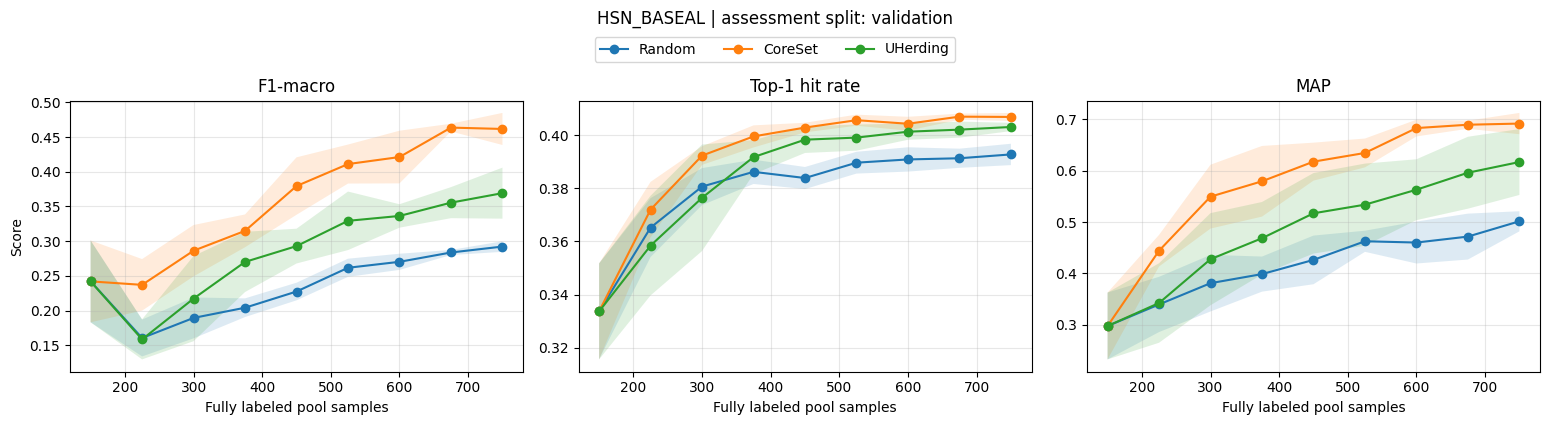

In [9]:
def plot_results(results, dataset_name):
    metric_names = list(METRIC_FUNCS.keys())
    fig, axes = plt.subplots(
        1, len(metric_names), figsize=(5.2 * len(metric_names), 4.0), sharex=True, tight_layout=True
    )
    if len(metric_names) == 1:
        axes = [axes]

    for ax_idx, (ax, metric_name) in enumerate(zip(axes, metric_names)):
        for strategy_name, runs in results.items():
            budgets = np.asarray(runs[0]["labeled_counts"], dtype=int)
            curves = np.asarray([run["metrics"][metric_name] for run in runs], dtype=float)
            mean_curve = curves.mean(axis=0)
            std_curve = curves.std(axis=0)

            label_dict = {"label": strategy_name} if ax_idx == 0 else {}
            ax.plot(budgets, mean_curve, marker="o", **label_dict)
            if len(runs) > 1:
                ax.fill_between(budgets, mean_curve - std_curve, mean_curve + std_curve, alpha=0.15)

        ax.set_title(metric_name)
        ax.set_xlabel("Fully labeled pool samples")
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Score")
    fig.legend(loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=len(results), frameon=True)
    fig.suptitle(f"{dataset_name} | assessment split: {dataset['assessment_split']}", y=1.05)
    plt.show()


plot_results(results, dataset_name=dataset["dataset_name"])